# Phase 1: Structural baseline

Assignment 3 used one hot degree features and got 75.1%. Here we change those to Local Degree Profile (https://arxiv.org/abs/2003.00982) plus clustering, PageRank, and BFS depth, cause one number per node throws away a lot of info. Same GCN, just better inputs.

11 features per node total:
- LDP block, 5 dims: degree and min/max/mean/std of neighbor degrees
- in degree and out degree, 2 dims
- local clustering coefficient
- PageRank score
- BFS depth from the highest degree node
- normalized degree

Tran et al. (https://arxiv.org/abs/2508.06734) report 85.6% on the standard split with LDP and global max pooling. We use mean pooling so will probably land a bit lower than that.


## 1. Setup

Clone the repo so we can import from src/. No-op if you already have it.


In [ ]:
# clone the repo on a fresh colab session, no-op if already there
import os
REPO = "malnet-shift-robustness"
if not os.path.exists(REPO):
    !git clone https://github.com/AdityaRao127/malnet-shift-robustness.git
%cd $REPO


Cloning into 'malnet-shift-robustness'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 63 (delta 28), reused 62 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 171.05 KiB | 951.00 KiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/malnet-shift-robustness


In [ ]:
# colab already has torch, grab the rest. pinning pyg avoids api drift
!pip install -q torch-geometric==2.7.0 scikit-learn pandas matplotlib tqdm numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.8 MB/s eta 0:00:00


In [ ]:
import os, sys, time, random, json
sys.path.insert(0, "src")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from data_loader import load_malnet_splits, make_loaders
from features import make_pre_transform
from model import BaselineGCN
from train import train_model, predict, build_metrics, save_metrics

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")


using device: cuda


## 2. Hyperparameters


In [ ]:
EPOCHS = 50
LR = 0.001
BATCH_SIZE = 64
HIDDEN_DIM = 64
FEATURE_TYPE = "structural"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)


## 3. Load Dataset with Structural Features

Note the root="data/structural/" so this cache does not collide with the degree-features cache from the original baseline notebook.


In [ ]:
pre_transform = make_pre_transform(feature_type=FEATURE_TYPE)

# separate root keeps caches isolated by feature config
train_ds, val_ds, test_ds = load_malnet_splits(
    root="data/structural/", pre_transform=pre_transform
)

print(f"train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")
print(f"features per node: {train_ds.num_features}")
print(f"classes: {train_ds.num_classes}")
print(f"sample: {train_ds[0]}")

# class names in pyg label order, parsed from the raw split files
raw_type_dir = os.path.join("data", "structural", "raw", "split_info_tiny", "type")
y_map = {}
for split_file in ["train.txt", "val.txt", "test.txt"]:
    with open(os.path.join(raw_type_dir, split_file)) as f:
        for line in f.read().strip().split("\n"):
            mtype = line.split("/")[0]
            y_map.setdefault(mtype, len(y_map))
CLASS_NAMES = [name for name, _ in sorted(y_map.items(), key=lambda x: x[1])]
print(f"classes (label order): {CLASS_NAMES}")


Extracting data/structural/raw/malnet-graphs-tiny.tar.gz
Extracting data/structural/raw/split_info_tiny.zip
Processing...
Done!


train: 3500 | val: 500 | test: 1000
features per node: 11
classes: 5
sample: Data(edge_index=[2, 3576], y=[1], x=[1679, 11], num_nodes=1679)
classes (label order): ['adware', 'benign', 'downloader', 'trojan', 'addisplay']


## 4. DataLoaders


In [ ]:
train_loader, val_loader, test_loader = make_loaders(train_ds, val_ds, test_ds, batch_size=BATCH_SIZE)

batch = next(iter(train_loader))
print(f"batch x shape: {batch.x.shape}")
print(f"batch y shape: {batch.y.shape}")


batch x shape: torch.Size([88752, 11])
batch y shape: torch.Size([64])


## 5. Model

Same BaselineGCN architecture from src/model.py, just with the wider 11-dim input.


In [ ]:
model = BaselineGCN(
    in_channels=train_ds.num_features,
    hidden_channels=HIDDEN_DIM,
    num_classes=train_ds.num_classes,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"total params: {n_params:,}")


BaselineGCN(
  (conv1): GCNConv(11, 64)
  (conv2): GCNConv(64, 64)
  (classifier): Linear(in_features=64, out_features=5, bias=True)
)
total params: 5,253


## 6. Training


In [ ]:
t0 = time.time()
model, train_losses, val_accs, best_val_acc = train_model(
    model, train_loader, val_loader, EPOCHS, LR, device, verbose_every=10
)
train_time = time.time() - t0
print(f"training done in {train_time:.1f}s, best val acc {best_val_acc:.4f}")


  Epoch 010 | Loss: 0.8273 | Val Acc: 0.6580
  Epoch 020 | Loss: 0.7637 | Val Acc: 0.7240
  Epoch 030 | Loss: 0.7105 | Val Acc: 0.7420
  Epoch 040 | Loss: 0.6658 | Val Acc: 0.7580
  Epoch 050 | Loss: 0.6418 | Val Acc: 0.7560
training done in 51.5s, best val acc 0.7700


## 7. Test Check


In [ ]:
test_preds, test_labels = predict(model, test_loader, device)

report = classification_report(test_labels, test_preds, target_names=CLASS_NAMES)
print(report)
test_acc = accuracy_score(test_labels, test_preds)
print(f"overall test accuracy: {test_acc:.4f}")

# delta vs assignment 3 baseline (one hot degree, 75.1%)
assn3_acc = 0.7510
print(f"assignment 3 baseline: {assn3_acc:.4f}")
print(f"this run (structural): {test_acc:.4f}")
print(f"delta: {test_acc - assn3_acc:+.4f}")


              precision    recall  f1-score   support

      adware       0.82      0.81      0.81       200
      benign       0.54      0.44      0.48       200
  downloader       0.97      0.99      0.98       200
      trojan       0.90      0.61      0.73       200
   addisplay       0.55      0.82      0.66       200

    accuracy                           0.74      1000
   macro avg       0.76      0.74      0.73      1000
weighted avg       0.76      0.74      0.73      1000

overall test accuracy: 0.7360
assignment 3 baseline: 0.7510
this run (structural): 0.7360
delta: -0.0150


## 8. Save Results

Outputs land in results/baseline_structural_*.{json,csv,png} so they do not overwrite the original baseline.


saved results/baseline_structural_metrics.json
saved results/baseline_structural_results.csv


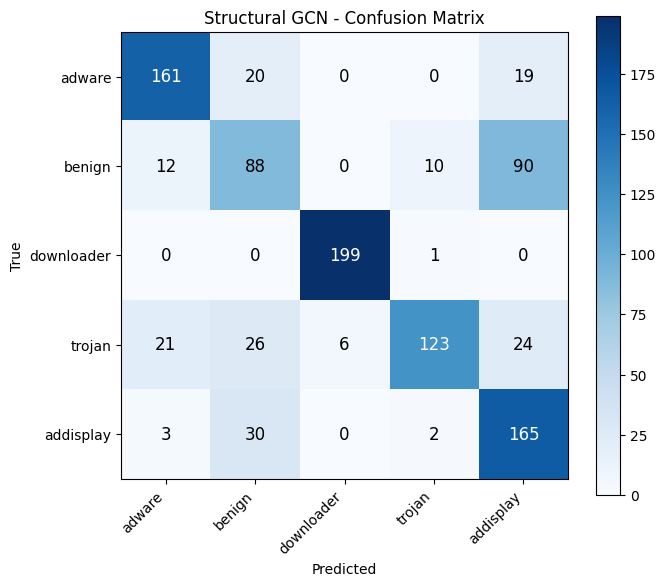

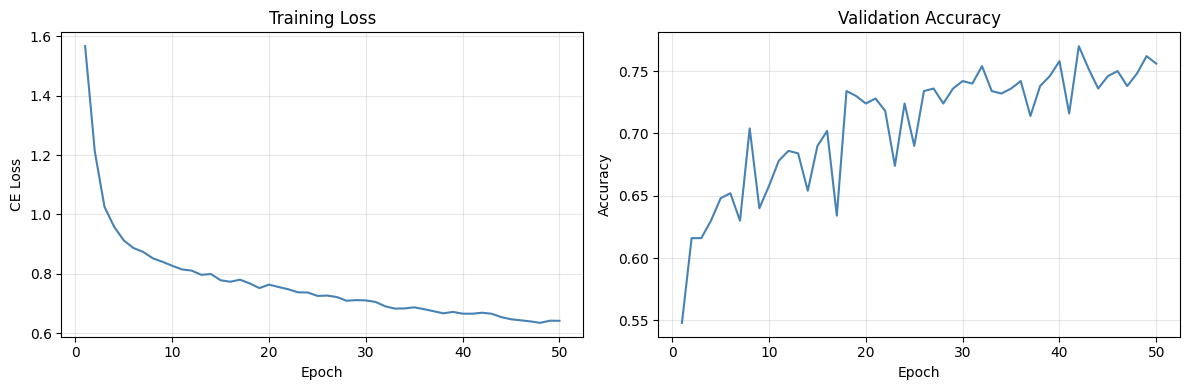

In [ ]:
cfg = {
    "epochs": EPOCHS, "learning_rate": LR, "batch_size": BATCH_SIZE,
    "hidden_dim": HIDDEN_DIM, "feature_type": FEATURE_TYPE,
    "optimizer": "Adam", "device": str(device),
}
metrics = build_metrics(test_preds, test_labels, CLASS_NAMES, cfg, best_val_acc, train_time)
json_path, csv_path = save_metrics(metrics, RESULTS_DIR, prefix="baseline_structural")
print("saved", json_path)
print("saved", csv_path)

# confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_title("Structural GCN - Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_yticklabels(CLASS_NAMES)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=12)
fig.colorbar(im)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "baseline_structural_confusion_matrix.png"), dpi=150)
plt.show()

# training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, EPOCHS+1), train_losses, color="steelblue")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("CE Loss"); ax1.set_title("Training Loss"); ax1.grid(alpha=0.3)
ax2.plot(range(1, EPOCHS+1), val_accs, color="steelblue")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Validation Accuracy"); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "baseline_structural_training_curve.png"), dpi=150)
plt.show()


## Summary

If the structural features carry more signal than degree alone, this should beat the 75.1% baseline. Phase 2 enhances the feature set further and starts simulating missingness during training.
